In [2]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 10.942 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.5.20  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.17       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.22.1     pyhcf101f3_0         conda-forge
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.2      py313h1804a44_3      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ 

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']

 Logistic Regression
Accuracy: 0.9824561403508771

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC Score: 0.9953703703703703


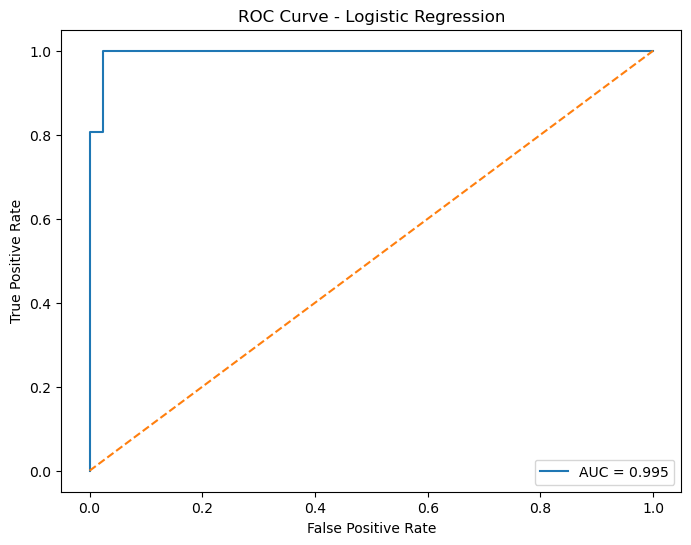


===== Decision Tree =====
Accuracy: 0.9385964912280702

Confusion Matrix:
[[39  3]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



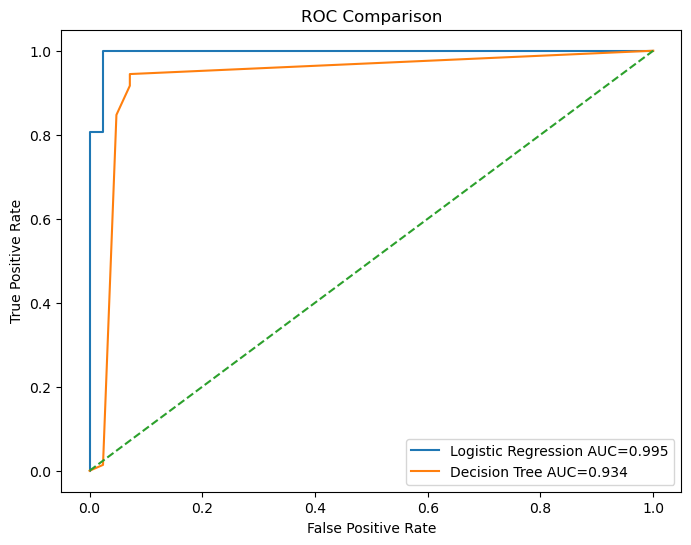

Decision Tree AUC: 0.9341931216931217

 Logistic Regression (Balanced) 
Accuracy: 0.956140350877193

Confusion Matrix:
[[41  1]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Model Comparison
                          Model  Accuracy
0           Logistic Regression  0.982456
1                 Decision Tree  0.938596
2  Logistic Regression Balanced  0.956140


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)


print("\n Logistic Regression")
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_log
)

auc_score = roc_auc_score(
    y_test,
    y_prob_log
)

print("AUC Score:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,
         label=f"AUC = {auc_score:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("\n===== Decision Tree =====")

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))


y_prob_tree = tree_model.predict_proba(X_test)[:,1]

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"Logistic Regression AUC={auc_score:.3f}")

plt.plot(fpr_tree, tpr_tree,
         label=f"Decision Tree AUC={tree_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

print("Decision Tree AUC:", tree_auc)

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=500
)

balanced_model.fit(
    X_train_scaled,
    y_train
)

y_pred_balanced = balanced_model.predict(
    X_test_scaled
)

print("\n Logistic Regression (Balanced) ")

print("Accuracy:",
      accuracy_score(y_test,
                     y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_balanced
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced
))

results = pd.DataFrame({
    "Model":["Logistic Regression",
        "Decision Tree",
        "Logistic Regression Balanced"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_balanced)
    ]
})

print("\nModel Comparison")
print(results)
                              
                            
